# Can we predict frequency of cannabis usage based on people's demographics, level of education, self-reported impulsivity levels, and gender?

In [86]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 
from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz 

from ucimlrepo import fetch_ucirepo 
  
# Fetching the dataset

drug_consumption = fetch_ucirepo(id=373) 

# Converting the dataset to a pandas dataframe

drugs_df = pd.concat([drug_consumption.data.features, drug_consumption.data.targets], axis=1)

drugs_df.info() # Printing variable types
drugs_df.head() # Printing the first five rows of the dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1885 non-null   float64
 1   gender     1885 non-null   float64
 2   education  1885 non-null   float64
 3   country    1885 non-null   float64
 4   ethnicity  1885 non-null   float64
 5   nscore     1885 non-null   float64
 6   escore     1885 non-null   float64
 7   oscore     1885 non-null   float64
 8   ascore     1885 non-null   float64
 9   cscore     1885 non-null   float64
 10  impuslive  1885 non-null   float64
 11  ss         1885 non-null   float64
 12  alcohol    1885 non-null   object 
 13  amphet     1885 non-null   object 
 14  amyl       1885 non-null   object 
 15  benzos     1885 non-null   object 
 16  caff       1885 non-null   object 
 17  cannabis   1885 non-null   object 
 18  choc       1885 non-null   object 
 19  coke       1885 non-null   object 
 20  crack   

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [87]:
# Only keeping necessary columns to predict cannabis usage

cannabis_df = drugs_df[['age', 'gender', 'education', 'country', 'ethnicity', 'impuslive', 'cannabis', 'nscore', 'escore', 'oscore', 'ascore', 'cscore', 'ss']]

cannabis_df = cannabis_df.dropna() # Dropping any NA values

cannabis_df.head() # Printing the first five rows of the new dataset

,age,gender,education,country,ethnicity,impuslive,cannabis,nscore,escore,oscore,ascore,cscore,ss
0,0.49788,0.48246,-0.05921,0.96082,0.12600,-0.21712,CL0,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-1.18084
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.71126,CL4,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.21575
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-1.37983,CL3,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,0.40148
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-1.37983,CL2,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.18084
4,0.49788,0.48246,1.98437,0.96082,-0.31685,-0.21712,CL3,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21575


In [88]:
cannabis_df[["cannabis"]] = OrdinalEncoder().fit_transform(cannabis_df[["cannabis"]]) # Ordinally encoding our target variable

print(cannabis_df['cannabis'].value_counts()) # Checking the statistics of each cannabis usage frequency category


cannabis
6.0    463
0.0    413
2.0    266
3.0    211
1.0    207
5.0    185
4.0    140
Name: count, dtype: int64


In [89]:
# Splitting the data

X = cannabis_df.drop(columns = 'cannabis') # Defining our feature variables
y = cannabis_df.cannabis # Defining our target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.70, stratify= y, random_state = 42)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state = 30)

In [90]:
# Starting the cross validation process with 10 splits and 5 repeats

kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 5, random_state=42)

In [91]:
# Defining our scoring metrics

scoring = {
    'roc_auc': 'roc_auc_ovr',             
    'recall': 'recall_macro',               
    'balanced_accuracy': 'balanced_accuracy'  
}



In [92]:
# Using max_depth as our hyperparameter

param={#"max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    # "min_samples_leaf":[12,3,4,5,6,7,8,9,10],
    #"min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    # "max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90] 
    # 'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    'ccp_alpha':[.001,.01,.1]
        }

In [93]:
cl = DecisionTreeClassifier(random_state=1000) # Defining the classifier model

# Searching for the best classifier based on balanced_accuracy

search = GridSearchCV(cl, param, scoring = scoring, n_jobs = -1, cv = kf, refit = 'balanced_accuracy') 

model = search.fit(X_train, y_train) # Fitting the model based on the training data

In [94]:
# Finding the best max_depth

best = model.best_estimator_
print(best)

DecisionTreeClassifier(ccp_alpha=0.001, random_state=1000)


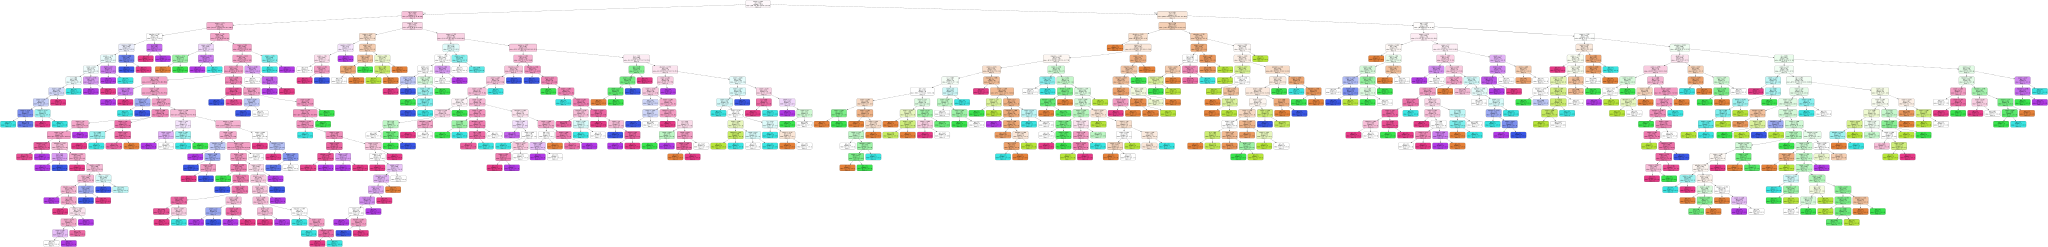

In [95]:
# Printing the decision tree

dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns,
               filled=True, 
                rounded=True, 
                class_names = ['0', '1', '2', '3', '4', '5', '6'])
               
graph=graphviz.Source(dot_data)
graph

In [96]:
print(model.cv_results_)

{'mean_fit_time': array([0.01126771, 0.00945205, 0.00951748]), 'std_fit_time': array([0.00506829, 0.00362412, 0.00280263]), 'mean_score_time': array([0.00813996, 0.00755134, 0.00616606]), 'std_score_time': array([0.00350204, 0.00489086, 0.00222621]), 'param_ccp_alpha': masked_array(data=[0.001, 0.01, 0.1],
             mask=[False, False, False],
       fill_value=1e+20), 'params': [{'ccp_alpha': 0.001}, {'ccp_alpha': 0.01}, {'ccp_alpha': 0.1}], 'split0_test_roc_auc': array([0.5810805 , 0.65593553, 0.5       ]), 'split1_test_roc_auc': array([0.56361601, 0.67008061, 0.5       ]), 'split2_test_roc_auc': array([0.57659951, 0.68503515, 0.5       ]), 'split3_test_roc_auc': array([0.60861821, 0.67110549, 0.5       ]), 'split4_test_roc_auc': array([0.55903104, 0.67617735, 0.5       ]), 'split5_test_roc_auc': array([0.52898117, 0.66142174, 0.5       ]), 'split6_test_roc_auc': array([0.55853056, 0.68697517, 0.5       ]), 'split7_test_roc_auc': array([0.57074689, 0.66763857, 0.5       ]), 'split

In [97]:
auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']


for key in param:
    params = str("param_" + key)

depth= np.unique(model.cv_results_[params])

final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

final_model

,depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
0,0.001,0.571542,0.242950,0.242950,0.022000,0.035490,0.035490
1,0.010,0.673524,0.233551,0.233551,0.021183,0.015722,0.015722
2,0.100,0.500000,0.142857,0.142857,0.000000,0.000000,0.000000


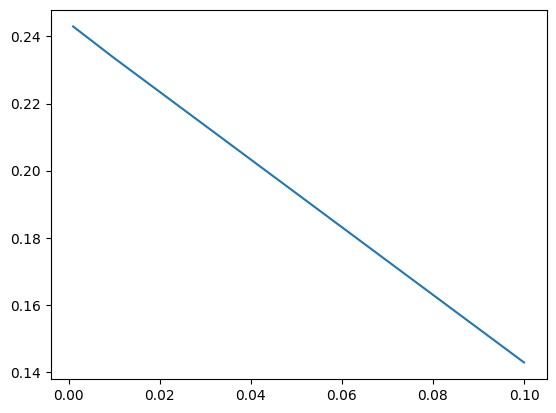

In [98]:
# Finding what depth has the highest balanced accuracy

print(plt.plot(final_model.depth,final_model.bal_acc))

In [99]:
varimp = pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

           importance
cscore       0.136114
ascore       0.117238
oscore       0.115007
escore       0.114198
country      0.101422
nscore       0.097384
ss           0.086972
impuslive    0.071763
education    0.065911
age          0.050554
gender       0.024152
ethnicity    0.019285


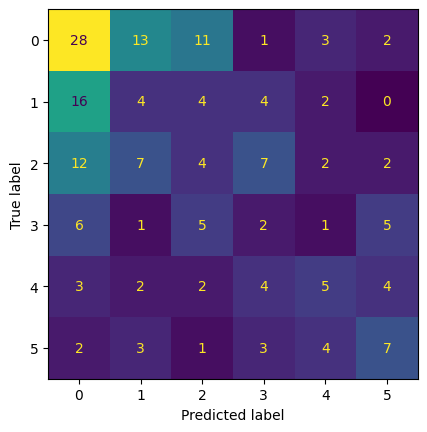

In [100]:
print(ConfusionMatrixDisplay.from_estimator(best, X_tune, y_tune, labels=[0, 1, 2, 3, 4, 5],colorbar=False))